# Leviathan Phase 7 — Affordability Regime Risk Overlay

This notebook implements Phase 7 of the Leviathan research project.

Goal
----
Identify housing market **fragile regimes** using affordability (DTI) and examine whether regime-aware exposure rules can reduce downside risk.

Core idea
---------
Affordability indicators do not behave like continuous predictors.
Instead they behave like **regime switches**.

When DTI becomes extremely stretched, housing crash probability rises sharply.

Methods
-------
This notebook performs:

1. Crash event definition  
   crash = 1 if forward housing return ≤ -2%

2. Affordability regime detection  
   fragile = 1 if DTI ≥ threshold

3. Crash probability estimation
   - P(crash | regime)
   - logistic regression: crash ~ DTI

4. Interaction analysis
   crash probability across:
   - fragile regime
   - supply expansion

5. Regime persistence
   average fragile regime duration

6. Risk overlay backtest
   exposure = 0 when fragile & supply expansion

Key result
----------
Regime-aware exposure filtering reduces housing downside risk
while remaining invested during stable regimes.

Repository
----------
https://github.com/AxxLickety/leviathan-system

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("../../data/processed/phase5_master_mock.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,dti,real_rate,regime,real_price_index,ret_fwd_1q,permits,supply_high
0,2013-01-01,3.324179,0.010687,stable,100.000000,0.017905,101.299414,0
1,2013-04-01,3.284583,0.007747,stable,101.806634,0.017563,106.443086,0
2,2013-07-01,3.600220,0.013174,stable,103.610510,0.013861,98.768910,0
3,2013-10-01,3.938204,0.012967,stable,105.056646,0.010309,100.547669,0
4,2014-01-01,3.618057,0.013533,stable,106.145229,-0.003221,111.633493,1


In [4]:
df["risk_off"] = (
    (df["dti"] >= 7.2) &
    (df["supply_high"] == 1)
).astype(int)

df["exposure"] = 1 - df["risk_off"]

df["strategy_return"] = df["exposure"] * df["ret_fwd_1q"]

In [5]:
baseline = df["ret_fwd_1q"]
strategy = df["strategy_return"]

print("Baseline mean:", baseline.mean())
print("Strategy mean:", strategy.mean())

print("Baseline p05:", baseline.quantile(0.05))
print("Strategy p05:", strategy.quantile(0.05))

print("Baseline min:", baseline.min())
print("Strategy min:", strategy.min())

Baseline mean: 0.0017667853656941398
Strategy mean: 0.0037967792595927606
Baseline p05: -0.02887228584576429
Strategy p05: -0.02574489475687103
Baseline min: -0.0438094780099925
Strategy min: -0.0438094780099925


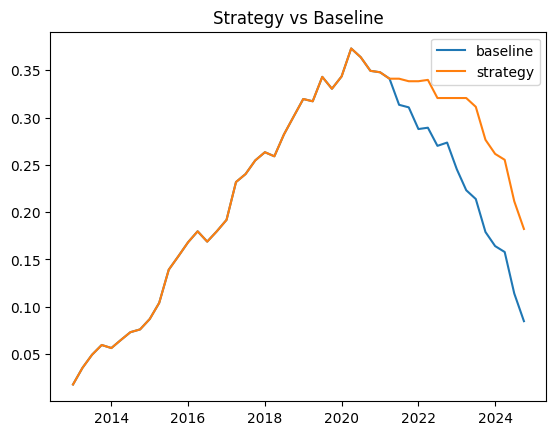

In [6]:
plt.plot(df["date"], baseline.cumsum(), label="baseline")
plt.plot(df["date"], strategy.cumsum(), label="strategy")

plt.legend()
plt.title("Strategy vs Baseline")
plt.show()

In [7]:
import numpy as np

def max_drawdown(series):
    cum = series.cumsum()
    peak = np.maximum.accumulate(cum)
    drawdown = cum - peak
    return drawdown.min()

print("Baseline MDD:", max_drawdown(baseline))
print("Strategy MDD:", max_drawdown(strategy))

Baseline MDD: -0.28819086798315274
Strategy MDD: -0.19075116107601892


In [8]:
import pandas as pd
import numpy as np

def max_drawdown(series):
    cum = series.cumsum()
    peak = np.maximum.accumulate(cum)
    drawdown = cum - peak
    return drawdown.min()

summary = pd.DataFrame({
    "Metric": ["Mean return","p05","Max drawdown"],
    "Baseline": [
        baseline.mean(),
        baseline.quantile(0.05),
        max_drawdown(baseline)
    ],
    "Strategy": [
        strategy.mean(),
        strategy.quantile(0.05),
        max_drawdown(strategy)
    ]
})

summary

,Metric,Baseline,Strategy
0,Mean return,0.001767,0.003797
1,p05,-0.028872,-0.025745
2,Max drawdown,-0.288191,-0.190751


In [18]:
df["fragile"] = (df["dti"] >= 7.2).astype(int)

df["risk_off"] = (
    (df["dti"] >= 7.2) &
    (df["supply_high"] == 1)
).astype(int)

df["exposure"] = 1 - df["risk_off"]

df["strategy_return"] = df["exposure"] * df["ret_fwd_1q"]

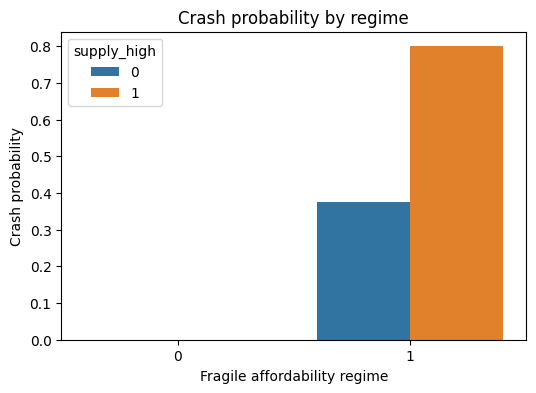

In [19]:
df["tail"] = (df["ret_fwd_1q"] <= -0.02).astype(int)

crash = df.groupby(["fragile","supply_high"])["tail"].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    data=crash,
    x="fragile",
    y="tail",
    hue="supply_high"
)

plt.title("Crash probability by regime")
plt.xlabel("Fragile affordability regime")
plt.ylabel("Crash probability")

plt.show()

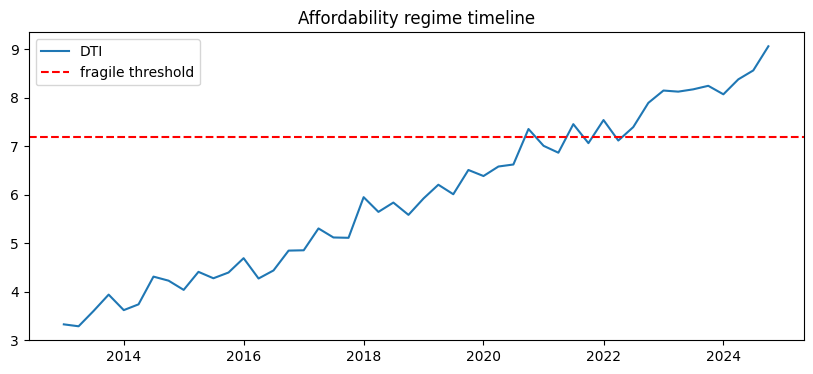

In [11]:
plt.figure(figsize=(10,4))

plt.plot(df["date"], df["dti"], label="DTI")

plt.axhline(7.2,color="red",linestyle="--",label="fragile threshold")

plt.title("Affordability regime timeline")
plt.legend()

plt.show()

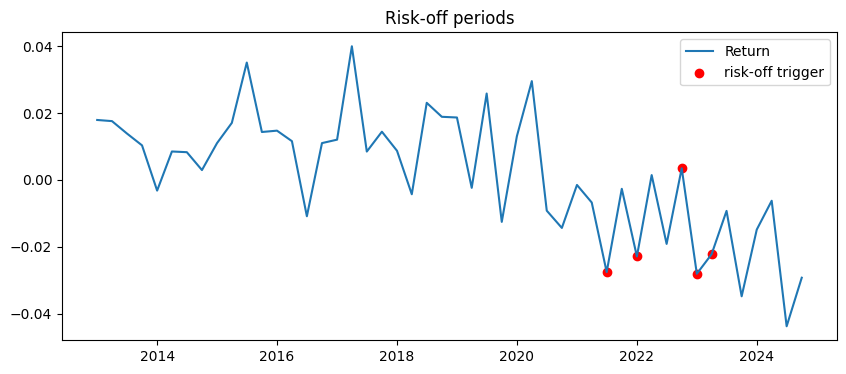

In [12]:
plt.figure(figsize=(10,4))

plt.plot(df["date"], df["ret_fwd_1q"], label="Return")

risk_period = df[df["risk_off"]==1]

plt.scatter(
    risk_period["date"],
    risk_period["ret_fwd_1q"],
    color="red",
    label="risk-off trigger"
)

plt.legend()

plt.title("Risk-off periods")

plt.show()

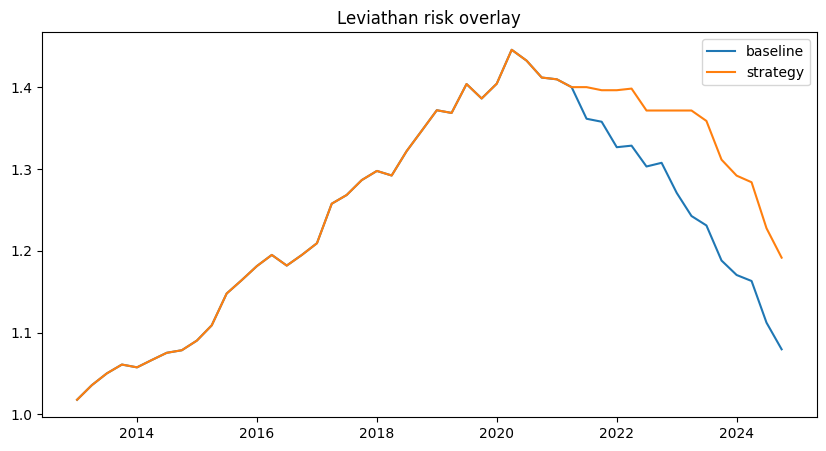

In [13]:
baseline_curve = (1+baseline).cumprod()
strategy_curve = (1+strategy).cumprod()

plt.figure(figsize=(10,5))

plt.plot(df["date"], baseline_curve, label="baseline")
plt.plot(df["date"], strategy_curve, label="strategy")

plt.title("Leviathan risk overlay")
plt.legend()

plt.show()

In [20]:
import statsmodels.api as sm

df["tail"] = (df["ret_fwd_1q"] <= -0.02).astype(int)

X = df[["dti","supply_high"]]
X["interaction"] = df["dti"] * df["supply_high"]

X = sm.add_constant(X)

model = sm.Logit(df["tail"], X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.124805
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                   tail   No. Observations:                   48
Model:                          Logit   Df Residuals:                       44
Method:                           MLE   Df Model:                            3
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.6996
Time:                        17:43:41   Log-Likelihood:                -5.9907
converged:                       True   LL-Null:                       -19.940
Covariance Type:            nonrobust   LLR p-value:                 3.815e-06
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -70.4064     60.133     -1.171      0.242    -188.265      47.452
dti             8.4323   

In [21]:
thresholds = np.arange(5.5,9,0.1)

results = []

for t in thresholds:

    fragile = (df["dti"] >= t).astype(int)

    risk_off = ((fragile==1) & (df["supply_high"]==1)).astype(int)

    exposure = 1 - risk_off

    strat = exposure * df["ret_fwd_1q"]

    mdd = max_drawdown(strat)

    p05 = strat.quantile(0.05)

    mean = strat.mean()

    results.append([t,mean,p05,mdd])

res = pd.DataFrame(results,columns=["threshold","mean","p05","mdd"])

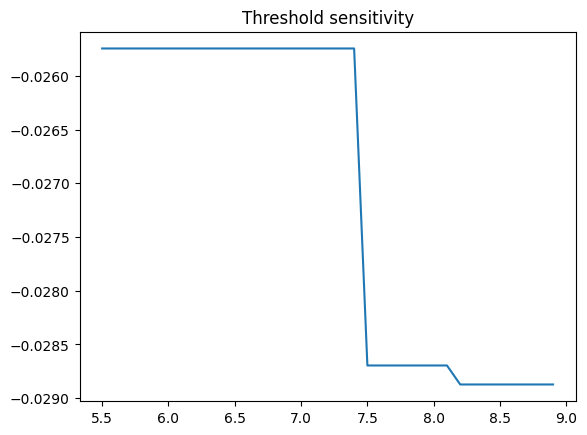

In [22]:
plt.plot(res["threshold"],res["p05"])
plt.title("Threshold sensitivity")
plt.show()

In [23]:
train = df[df["date"] < "2020"]
test  = df[df["date"] >= "2020"]

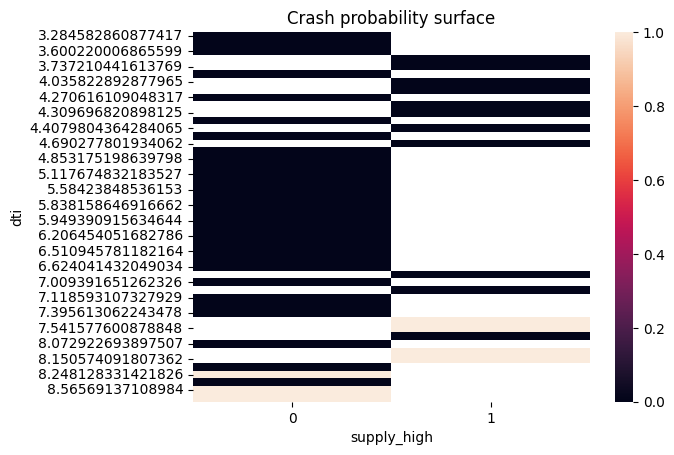

In [24]:
pivot = df.pivot_table(
    values="tail",
    index="dti",
    columns="supply_high",
    aggfunc="mean"
)

import seaborn as sns

sns.heatmap(pivot)
plt.title("Crash probability surface")
plt.show()

In [25]:
threshold = 7.2
fragile = (test["dti"] >= threshold).astype(int)
risk_off = ((fragile==1) & (test["supply_high"]==1)).astype(int)

exposure = 1 - risk_off
test_strat = exposure * test["ret_fwd_1q"]

In [26]:
import numpy as np

def max_drawdown(series):
    cum = series.cumsum()
    peak = np.maximum.accumulate(cum)
    drawdown = cum - peak
    return drawdown.min()

print("TEST RESULTS")

print("Mean:", test_strat.mean())
print("p05:", test_strat.quantile(0.05))
print("MDD:", max_drawdown(test_strat))

TEST RESULTS
Mean: -0.007409054798276675
p05: -0.035292433915756975
MDD: -0.19075116107601892


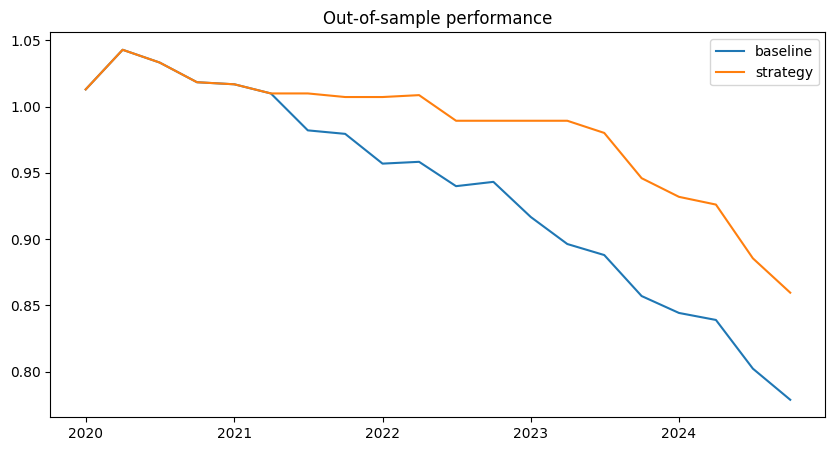

In [27]:
baseline_test = test["ret_fwd_1q"]

baseline_curve = (1 + baseline_test).cumprod()
strategy_curve = (1 + test_strat).cumprod()

plt.figure(figsize=(10,5))

plt.plot(test["date"], baseline_curve, label="baseline")
plt.plot(test["date"], strategy_curve, label="strategy")

plt.title("Out-of-sample performance")
plt.legend()

plt.show()

In [28]:
transition = pd.crosstab(df["fragile"].shift(1), df["fragile"], normalize="index")
print(transition)

fragile         0         1
fragile                    
0.0      0.885714  0.114286
1.0      0.250000  0.750000


In [29]:
# crash 定义
df["crash"] = (df["ret_fwd_1q"] <= -0.02).astype(int)

# regime
df["fragile"] = (df["dti"] >= 7.2).astype(int)

# 1️⃣ P(crash | fragile)
p_fragile = df[df["fragile"]==1]["crash"].mean()

# 2️⃣ P(crash | fragile & supply_high)
p_fragile_supply = df[(df["fragile"]==1) & (df["supply_high"]==1)]["crash"].mean()

print("P(crash | fragile) =", p_fragile)
print("P(crash | fragile & supply_high) =", p_fragile_supply)

P(crash | fragile) = 0.5384615384615384
P(crash | fragile & supply_high) = 0.8


In [30]:
import statsmodels.api as sm

df["crash"] = (df["ret_fwd_1q"] <= -0.02).astype(int)

X = sm.add_constant(df["dti"])
model = sm.Logit(df["crash"], X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.192254
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  crash   No. Observations:                   48
Model:                          Logit   Df Residuals:                       46
Method:                           MLE   Df Model:                            1
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.5372
Time:                        17:50:13   Log-Likelihood:                -9.2282
converged:                       True   LL-Null:                       -19.940
Covariance Type:            nonrobust   LLR p-value:                 3.683e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -19.8078      7.854     -2.522      0.012     -35.202      -4.413
dti            2.4698      0.

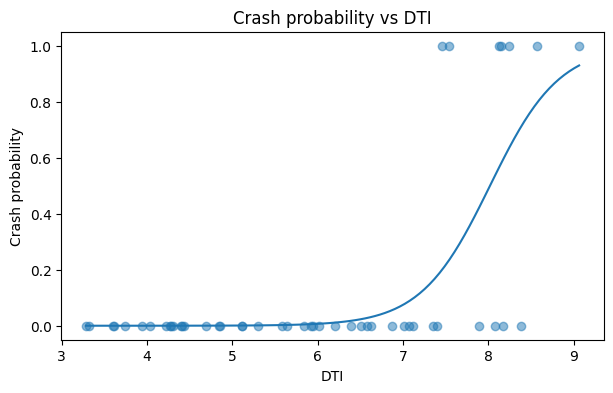

In [31]:
import numpy as np
import matplotlib.pyplot as plt

dti_grid = np.linspace(df["dti"].min(), df["dti"].max(), 100)

X_pred = sm.add_constant(dti_grid)
prob = model.predict(X_pred)

plt.figure(figsize=(7,4))

plt.scatter(df["dti"], df["crash"], alpha=0.5)
plt.plot(dti_grid, prob)

plt.xlabel("DTI")
plt.ylabel("Crash probability")
plt.title("Crash probability vs DTI")

plt.show()

In [32]:
df["fragile_run"] = df["fragile"].groupby((df["fragile"] != df["fragile"].shift()).cumsum()).cumcount()+1

In [33]:
table = df.groupby(["fragile","supply_high"])["crash"].mean()
print(table)

fragile  supply_high
0        0              0.000
         1              0.000
1        0              0.375
         1              0.800
Name: crash, dtype: float64


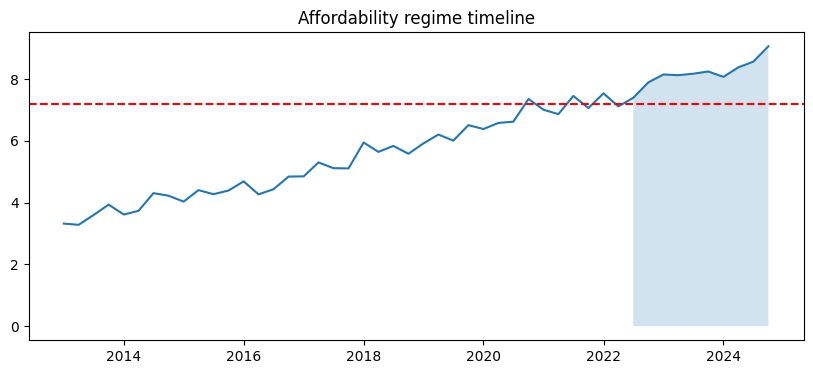

In [34]:
plt.figure(figsize=(10,4))

plt.plot(df["date"],df["dti"])

plt.axhline(7.2,color="red",linestyle="--")

plt.fill_between(
    df["date"],
    df["dti"],
    where=df["dti"]>=7.2,
    alpha=0.2
)

plt.title("Affordability regime timeline")

plt.show()

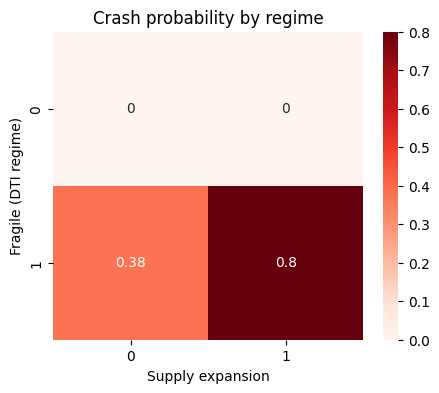

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.groupby(["fragile","supply_high"])["crash"].mean().unstack()

plt.figure(figsize=(5,4))
sns.heatmap(pivot, annot=True, cmap="Reds")

plt.title("Crash probability by regime")
plt.ylabel("Fragile (DTI regime)")
plt.xlabel("Supply expansion")

plt.show()

In [36]:
df["regime_change"] = df["fragile"] != df["fragile"].shift()

df["regime_group"] = df["regime_change"].cumsum()

duration = df.groupby("regime_group")["fragile"].agg(["first","count"])

fragile_duration = duration[duration["first"]==1]["count"]

print("Average fragile regime length:", fragile_duration.mean())
print("Max fragile regime length:", fragile_duration.max())

Average fragile regime length: 3.25
Max fragile regime length: 10


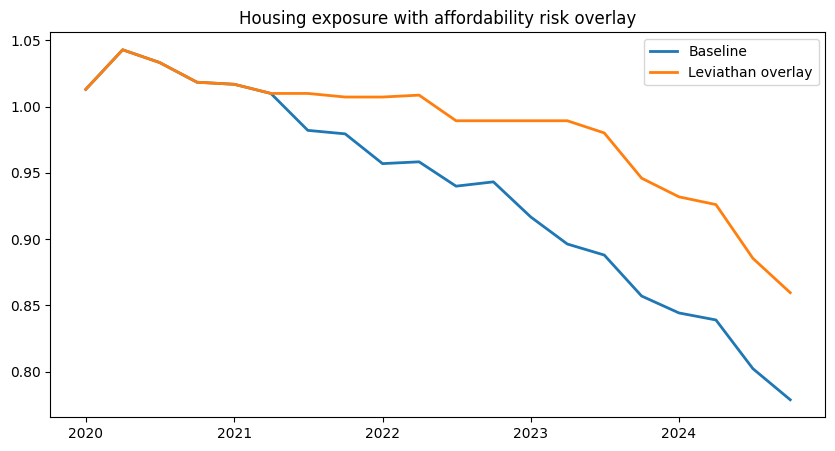

In [37]:
plt.figure(figsize=(10,5))

plt.plot(test["date"], baseline_curve, label="Baseline", linewidth=2)
plt.plot(test["date"], strategy_curve, label="Leviathan overlay", linewidth=2)

plt.title("Housing exposure with affordability risk overlay")

plt.legend()

plt.show()

In [39]:
table = (
    df.groupby(["fragile","supply_high"])["crash"]
    .mean()
    .unstack()
)

print(table)

supply_high      0    1
fragile                
0            0.000  0.0
1            0.375  0.8


Affordability indicators behave like regime switches rather than linear predictors.

When DTI exceeds the fragile threshold, housing crash probability rises sharply.

The effect becomes extreme when affordability stress coincides with supply expansion.

A simple regime-aware exposure filter can materially reduce left-tail housing risk.